In [20]:
# Purpose:
# Import the libraries and reusable modules needed for Exercise 3

# Source of Code and Justification:
# Exercise 3 builds on the cortical field model from Exercise 2.

# Approach:
# - Add the project root to import modules from src/.
# - Import NumPy and Matplotlib.
# - Import the connectivity functions and the EIUnit class
# - Define the figures directory for saving Exercise 3 plots.

# What to say in Report:
# “For Exercise 3, we reused the cortical field model implemented in Exercise 2.
# We still simulate multiple E-I units coupled through a connectivity matrix W,
# but now we study how localized external stimuli affect network activity.

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

from src.connectivity import generate_sparse_connectivity, generate_unit_connectivity, ring_distance
from src.ei_unit import EIUnit, population_rate_hz

In [21]:
# Purpose:
# Define the network, simulation, and stimulus parameters for Exercise 3.

# Source of Code and Justification:
# Exercise 3 reuses the cortical field model and E/I parameters from Exercises 1 and 2.

# Approach:
# - Reuse the within-unit parameters from Exercise 1 (NE, gamma, p, g, J, tau_delay, LIF, background).
# - Reuse the ring parameters from Exercise 2 (Nunits, sigma, W0).
# - Define the stimulus parameters for Exercise 3.1 (I0, time_onset_ms, stim_exc_unit).

# What to say in Report:
# "Exercise 3 uses the same cortical field model as Exercise 2."

# Number of E-I units for the cortical sheet
Nunits = 10

# Within-unit E/I network parameters from Exercise 1
NE = 1000
gamma = 0.25
NI = int(gamma * NE)
N = NE + NI

p = 0.02
KE = int(p * NE)
KI = int(p * NI)

J = 45.0          # pC
g = 5.0
tau_delay = 2.0  # ms

# LIF neuron parameters
theta = 20.0      # mV
u_reset = -10.0   # mV
R = 1.0           # MOhm
dt = 0.5          # ms
tau_m = 20.0      # ms

# Stochastic background input
n_bg = 25.0
bg_scale = 1.0

# Simulation time
T_ms = 200.0
n_steps = int(round(T_ms / dt))
time_ms = np.arange(n_steps) * dt

# Ring parameters
sigma = 0.2
W0 = 45.0      # pC

#Parameters for ex 3.1
I0 = 30.0     # nA
time_onset_ms = 100.0
stim_exc_unit = 5

Initialized 10 E-I units.
W_unit shape: (20, 20)
I0 = 30.0 nA, sigma = 0.2, W0 = 45.0 pC
Simulation complete.


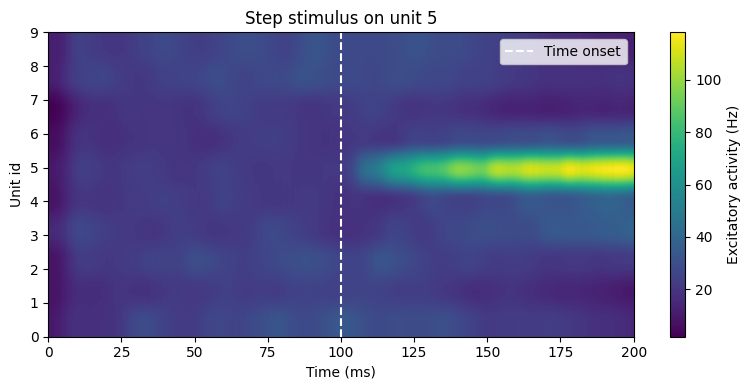

In [ ]:
# Purpose:
# Initialize  and simulate the cortical field model for Exercise 3.1 with a step external stimulus, to
# finally plot the 2D excitatory activity map 

# Source of Code and Justification:
# Exercise 3.1 reuses the same coupled field model as Exercise 2.4 : multiple E-I units connected through 
# the population-level matrix W_unit. It also asks for applying a step input to the excitatory population 
# of unit 5 for I_ext,E(t) = I0, for t >= 100 ms, with I0 = 30 nA, T = 200 ms, and W0 = 45 pC. The unit-unit 
# input is still computed as in Exercise 2.4 : I_unit = W_unit @ r_delayed. It finally asks for the same type 
# of plot as Exercise 2.4.

# Approach:
# - Generate W_unit using generate_unit_connectivity with W0 = 45 pC.
# - Create one independent EIUnit per spatial location and store them in a list as before.
# - Build delayed population activity vector [r_E, r_I] with synaptic delay and compute spatial coupling 
#   through W_unit @ r_delayed.
# - Add the step stimulus to I_E_units[stim_exc_unit] when t >= time_onset_ms.
# - Convert population activity from 1/ms to Hz (multiply by 1000) and plot a space-time heatmap.



W_unit, x = generate_unit_connectivity(Nunits, sigma, W0, g, gamma)
seed = 99
units = []

for unit_id in range(Nunits):

    W_recurrent = generate_sparse_connectivity(
        NE=NE,
        NI=NI,
        KE=KE,
        KI=KI,
        J=J,
        g=g,
        seed=seed + unit_id,
    )

    unit = EIUnit(
        W=W_recurrent,
        NE=NE,
        dt=dt,
        tau_m=tau_m,
        R=R,
        theta=theta,
        u_reset=u_reset,
        tau_delay_ms=tau_delay,
        n_bg=n_bg,
        bg_scale=bg_scale,
        rng=np.random.default_rng(seed + 1000 + unit_id),
    )
    units.append(unit)


print(f"Initialized {len(units)} E-I units.")
print("W_unit shape:", W_unit.shape)
print(f"I0 = {I0} nA, sigma = {sigma}, W0 = {W0} pC")


delay_steps = int(round(tau_delay / dt))
alpha_rate = 0.98

r_E = np.zeros((n_steps, Nunits), dtype=float)
r_I = np.zeros((n_steps, Nunits), dtype=float)

for k in range(n_steps):

    if k >= delay_steps:
        delayed_activity = np.concatenate([
            r_E[k - delay_steps],
            r_I[k - delay_steps],
        ])

    else:
        delayed_activity = np.zeros(2 * Nunits, dtype=float)

    # Unit-level synaptic input (pC * 1/ms -> nA)
    I_unit = W_unit @ delayed_activity
    I_E_units = I_unit[:Nunits].copy()
    I_I_units = I_unit[Nunits:]

    if time_ms[k] >= time_onset_ms:
        I_E_units[stim_exc_unit] += I0
        
    for alpha, unit in enumerate(units):
        _, _, rE_alpha, rI_alpha = unit.step(
            I_E=I_E_units[alpha],
            I_I=I_I_units[alpha],
        )
        if k == 0:
            r_E[k, alpha] = rE_alpha
            r_I[k, alpha] = rI_alpha
        else:
            r_E[k, alpha] = (
                alpha_rate * r_E[k - 1, alpha]
                + (1.0 - alpha_rate) * rE_alpha
            )
            r_I[k, alpha] = (
                alpha_rate * r_I[k - 1, alpha]
                + (1.0 - alpha_rate) * rI_alpha
            )
            
print("Simulation complete.")

r_E_hz = 1000.0 * r_E

plt.figure(figsize=(8, 4))
plt.imshow(
    r_E_hz.T,
    aspect="auto",
    origin="lower",
    extent=[0, T_ms, 0, Nunits - 1],
)

plt.axvline(time_onset_ms, color="white", linestyle="--", linewidth=1.5, label="Time onset")
plt.colorbar(label="Excitatory activity (Hz)")
plt.xlabel("Time (ms)")
plt.ylabel("Unit id")
plt.title(f"Step stimulus on unit {stim_exc_unit}")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "ex3_1_step_stimulus_unit_5.png", dpi=300)
plt.show()